In [1]:
### This is an almost exact copy of Tabular_Regularization.
### The only difference is that here we impose *no* regularization.
### This is controlled by setting gamma_val = 0.0 in the training configuration class.

import numpy as np
import matplotlib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import random
from dataclasses import dataclass
from typing import Dict, Callable, Tuple, Optional

from symdisc.discovery import make_model_jacobian_callable_torch
from symdisc.enforcement.regularization.penalties import forward_with_invariance_penalty
from symdisc.enforcement.regularization.schedules import jump

#matplotlib.use('QtAgg') # Or 'Qt5Agg', 'QtAgg', 'WebAgg', 'TkAgg', etc.
import matplotlib.pyplot as plt
import time

from symdisc import (
    LSE,
    getExtendedFeatureMatrix,
    discover_symmetry_coeffs,
    generate_euclidean_killing_fields_with_names,
)

In [2]:
# -------------------------
# Reproducibility
# -------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1337)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# -------------------------
# Synthetic dataset
# -------------------------
class XYZRDataset(Dataset):
    """
    Points in R^3 with target t = exp(x^2 + y^2).
    A split can be made via the half-plane y >= 0 (train) vs y < 0 (test).
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        assert X.shape[1] == 3
        assert y.ndim == 1 or (y.ndim == 2 and y.shape[1] == 1)
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y.reshape(-1, 1)).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def generate_points(n_total: int = 1000,
                    xy_range: float = 1.5,
                    z_range: float = 1.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate points uniformly in x,y ∈ [-xy_range, xy_range], z ∈ [-z_range, z_range]
    Target t = exp(x^2 + y^2).
    """
    X = np.empty((n_total, 3), dtype=np.float32)
    for i in range(n_total):
        x = np.random.uniform(-xy_range, xy_range)
        y = np.random.uniform(-xy_range, xy_range)
        z = np.random.uniform(-z_range, z_range)
        X[i] = (x, y, z)
    y = np.exp(X[:, 0]**2 + X[:, 1]**2) # + X[:, 2]**2)
    return X, y


def split_upper_lower_half_plane(X: np.ndarray, y: np.ndarray, upper_ratio=0.5):
    """
    Split the dataset by half-plane:
      - Train: y >= 0 (upper half-plane)
      - Test:  y < 0 (lower half-plane)
    If proportions are imbalanced, we still just use the predicate split.
    """
    upper_mask = X[:, 1] >= 0.0
    lower_mask = ~upper_mask

    X_train, y_train = X[upper_mask], y[upper_mask]
    X_test, y_test = X[lower_mask], y[lower_mask]

    # If either split is empty (unlikely), fallback to random split (just in case)
    if len(X_train) == 0 or len(X_test) == 0:
        n = len(X)
        idx = np.random.permutation(n)
        split = int(n * upper_ratio)
        train_idx, test_idx = idx[:split], idx[split:]
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_test, y_test

In [4]:
# -------------------------
# Small MLP regressor
# -------------------------
class SmallRegressor(nn.Module):
    def __init__(self, hidden=64, act="silu"):
        super().__init__()
        act_layer = nn.SiLU() if act == "silu" else nn.GELU()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            act_layer,
            nn.Linear(hidden, hidden),
            act_layer,
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [5]:
# -------------------------
# Training utilities
# -------------------------
@dataclass
class TrainConfig:
    batch_size: int = 128
    epochs: int = 500
    lr: float = 1e-3
    weight_decay: float = 0.0
    lambda_R01: float = 1.0        # weight for rotation invariance penalty
    lambda_T2: float = 1.0         # initially off; set >0 to enforce z-translation too
    gamma_val: float = 0.5             # this should be strictly between 0 and 1
    gamma_wait: int = epochs//2
    print_every: int = 50


def evaluate(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    model.eval()
    sse = 0.0
    mae = 0.0
    sum_y = 0.0
    sum_y2 = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            yhat = model(xb)

            sse += F.mse_loss(yhat, yb, reduction="sum").item()
            mae += F.l1_loss(yhat, yb, reduction="sum").item()

            sum_y  += float(yb.sum())
            sum_y2 += float((yb**2).sum())
            n += yb.numel()

    mse = sse / n
    mae = mae / n
    # SST relative to the split mean
    ybar = sum_y / n
    sst = max(sum_y2 - n * (ybar ** 2), 1e-12)  # guard against degenerate SST
    r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")

    return {
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
    }

## Now get the data, symmetries, set training configurations.

In [6]:
X, y = generate_points(n_total=4000, xy_range=1.5, z_range=1.0)
X_train, y_train, X_test, y_test = split_upper_lower_half_plane(X, y)

# Euclidean Killing fields in ambient R^3
kvs, names = generate_euclidean_killing_fields_with_names(d=X.shape[1])

# Dataloaders
train_ds = XYZRDataset(X_train, y_train)
test_ds = XYZRDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, drop_last=False)

# Model + config
model = SmallRegressor(hidden=32, act="silu").to(device)
cfg = TrainConfig(
    batch_size=128,
    epochs=2000,
    lr=1e-3,
    weight_decay=1e-4,
    lambda_R01=1.0,  # start with rotation invariance only
    lambda_T2=0.0,   # set to >0 later to test z-translation invariance
    print_every=50,
    gamma_val=0.0,   # setting this to zero means no regularization.
    gamma_wait=100
)

opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
model_criterion = nn.MSELoss()

Rxy, Tz = kvs[3], kvs[2]

active_fields = []
weights = []

if cfg.lambda_R01 > 0.0:
    active_fields.append(Rxy)
    weights.append(cfg.lambda_R01)

if cfg.lambda_T2 > 0.0:
    active_fields.append(Tz)
    weights.append(cfg.lambda_T2)

## Train

In [7]:
penalties_scaled = False

gamma_schedule = jump(cfg.gamma_val, cfg.gamma_wait)

for epoch in range(1, cfg.epochs + 1):
    model.train()
    running_mse = 0.0
    running_total = 0.0
    n_obs = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        gamma = float(gamma_schedule(epoch))

        if gamma!=0.0:
            yhat, sym_pen = forward_with_invariance_penalty(
                model=model,
                X=active_fields,
                x=xb,
                loss=torch.nn.MSELoss(), #torch.nn.L1Loss(), #
                weights=weights
            )
        else:
            yhat, sym_pen = model(xb), torch.tensor(0.0)

        model_loss = model_criterion(yhat, yb)

        if not penalties_scaled and gamma!=0.0:
            #print("hi")
            scale = model_loss.detach()/torch.max(sym_pen.detach(), torch.tensor(1e-8))
            penalties_scaled=True
        else:
            #print("hello")
            scale = 1.0

        loss = (1-gamma)*model_loss + gamma*scale*sym_pen

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        running_mse += float(model_loss.detach()) * yb.size(0)
        running_total += float(loss.detach()) * yb.size(0)
        n_obs += yb.size(0)


    if epoch % cfg.print_every == 0 or epoch == 1 or epoch == cfg.epochs:
        print("Model loss: " , (1-gamma)*model_loss.detach())
        print("Symmetry loss: ", gamma*scale*sym_pen.detach())
        train_metrics = evaluate(model, train_loader)
        test_metrics = evaluate(model, test_loader)
        print(f"[{epoch:03d}/{cfg.epochs}] "
              f"Train MSE: {train_metrics['MSE']:.4f}, R2: {train_metrics['R2']:.4f} | "
              f"Test MSE: {test_metrics['MSE']:.4f}, R2: {test_metrics['R2']:.4f} | "
              f"λ_R01={cfg.lambda_R01:.2f}, λ_T2={cfg.lambda_T2:.2f}")

Model loss:  tensor(90.3264)
Symmetry loss:  tensor(0.)
[001/2000] Train MSE: 138.6918, R2: -0.5974 | Test MSE: 135.9494, R2: -0.6032 | λ_R01=1.00, λ_T2=0.00
Model loss:  tensor(12.2137)
Symmetry loss:  tensor(0.)
[050/2000] Train MSE: 22.0994, R2: 0.7455 | Test MSE: 144.5899, R2: -0.7051 | λ_R01=1.00, λ_T2=0.00
Model loss:  tensor(25.9375)
Symmetry loss:  tensor(0.)
[100/2000] Train MSE: 5.0686, R2: 0.9416 | Test MSE: 117.2561, R2: -0.3827 | λ_R01=1.00, λ_T2=0.00
Model loss:  tensor(0.9817)
Symmetry loss:  tensor(0.)
[150/2000] Train MSE: 1.7962, R2: 0.9793 | Test MSE: 119.0071, R2: -0.4034 | λ_R01=1.00, λ_T2=0.00
Model loss:  tensor(0.4116)
Symmetry loss:  tensor(0.)
[200/2000] Train MSE: 1.0428, R2: 0.9880 | Test MSE: 118.6446, R2: -0.3991 | λ_R01=1.00, λ_T2=0.00
Model loss:  tensor(0.4600)
Symmetry loss:  tensor(0.)
[250/2000] Train MSE: 0.7186, R2: 0.9917 | Test MSE: 113.8998, R2: -0.3432 | λ_R01=1.00, λ_T2=0.00
Model loss:  tensor(0.3183)
Symmetry loss:  tensor(0.)
[300/2000] Tra

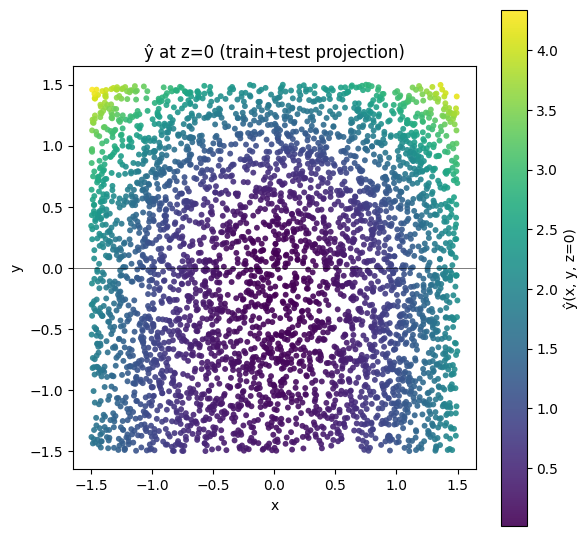

In [8]:
def plot_xy_projection_at_z0(
    model: nn.Module,
    X_np: np.ndarray,
    *,
    title: str = "ŷ(x, y, z=0) over data support",
    cmap: str = "viridis",
    s: float = 18.0,
    alpha: float = 0.9,
    fname: Optional[str] = None
):
    """
    Project data to z=0, color by model prediction at z=0.
    X_np: (N, 3) numpy array of original points (x, y, z).
    """
    model.eval()
    X = torch.from_numpy(X_np.astype(np.float32, copy=False)).to(device)
    X_proj = X.clone()
    X_proj[:, 2] = 0.0

    with torch.no_grad():
        yhat = model(X_proj).squeeze(-1).detach().cpu().numpy()

    x = X_np[:, 0]
    y = X_np[:, 1]

    fig, ax = plt.subplots(figsize=(6.0, 5.6))
    sc = ax.scatter(x, y, c=np.log(yhat), cmap=cmap, s=s, alpha=alpha, edgecolor="none")
    ax.axhline(0.0, color="k", lw=0.6, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("ŷ(x, y, z=0)")
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=160, bbox_inches="tight")
    plt.show()

X_all = np.vstack([X_train, X_test])  # or just X  # original numpy arrays
plot_xy_projection_at_z0(model, X_all, title="ŷ at z=0 (train+test projection)")#, fname="xy_pred_z0.png")

In [9]:
# now conduct symmetry discovery

# Build evaluation set: train+test or just test to probe OOD symmetry
X_eval_np = np.vstack([X_train, X_test]).astype(np.float32, copy=False)
X_eval = torch.from_numpy(X_eval_np).to(device)

# Jacobian callable for the trained model
J_callable = make_model_jacobian_callable_torch(model, batch_size=256, create_graph=False)

# Euclidean Killing fields with names (input-space)
#kvs, names = generate_euclidean_killing_fields_with_names(d=3)  # or generate_euclidean_killing_fields + your own names

# Extended feature matrix A and SVD-based discovery
A, shape_info = getExtendedFeatureMatrix(
    X=X_eval,                 # (N, d) torch.Tensor
    J=J_callable,             # callable returning (N, m, d)
    vector_fields=kvs,        # list of VF callables (batch-aware)
    normalize_rows=True,
    backend="torch"           # force Torch path
)
C, svals = discover_symmetry_coeffs(A, backend="torch")
#print(C)
print(svals)

#print("Discovered coefficient matrix C (q × r):", tuple(C.shape))
#print("Small singular values:", svals if isinstance(svals, np.ndarray) else svals.detach().cpu().numpy())
#print("Field names:", names)

# Pretty print top contributors
def print_top_components(C, names, topk=4):
    C_np = C.detach().cpu().numpy() if hasattr(C, "detach") else np.asarray(C)
    for j in range(C_np.shape[1]):
        coeffs = C_np[:, j]
        order = np.argsort(-np.abs(coeffs))
        print(f"\nSymmetry #{j+1}:")
        for idx in order[:topk]:
            print(f"  {names[idx]:>6s}: {coeffs[idx]: .4f}")

print_top_components(C, names, topk=6)

tensor([3.1440])

Symmetry #1:
     T_2:  0.9979
   R_1_2:  0.0493
   R_0_1: -0.0322
     T_1: -0.0238
   R_0_2:  0.0072
     T_0:  0.0042
